# Homework 3: Download and analyze any data using tools you learned in class

### IMPORTANT: Save your notebook and files (if you import locally) 
### IMPORTANT: See my example data folder: data/hw/hw_3/cory-baird
### **HW Requirements**

- **Relative Paths Only**
  - Use relative paths from the project root (e.g., `data/hw/hw_3/student-name/data.csv`).
  - Never hardcode absolute paths specific to your local machine (e.g., `/Users/username/...`).
- **File Size Limit**
  - Any committed dataset must be reasonable in size (strictly under 10 megabytes).
    - If you have to filter the dataset (to make it smaller) and upload a smaller version

- **Dataset Selection**
  - Select a policy-relevant dataset with at least 50 observations (e.g., 50 states, countries, or time periods) for meaningful analysis.
  - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Data Acquisition**
  - You are highly encouraged to fetch data programmatically using an API (e.g. using `requests` with World Bank, US Census, or other public APIs) or load a direct public URL.

  - Alternatively, you may upload a local file, provided it is committed to your repository.
    - If you read csv/parquet etc use relative paths such as `data/hw/hw_3/student-name/data.csv`.
    - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Reproducibility**
  - Commit both this notebook and the dataset so that your grader can run all cells from top to bottom out-of-the-box.

## IMPORTANT

---
### **Objectives**
- Select, acquire, and load a policy-relevant dataset of your choice.
- Apply clean code principles (environment checks, Python collections, standardized variable naming).
- Preprocess and standardize columns using Pandas techniques.
- Programmatically merge your primary dataset with a secondary source.
- Segment your data and run custom aggregations (using groupby or custom grouping strategies).
- Create customized visualizations and run exploratory regression analysis to discover policy insights.

### **Concept Reference Map**
- **Data Acquisition**: APIs (`requests` library), reading Parquet/CSV (Week 2/3 basics, Week 4 `1-visualization_basics.ipynb`)
- **Data Manipulation**: Selecting, renaming columns, filtering (`query()`), dropping NaNs (Week 4 `1-visualization_basics.ipynb`)
- **Aggregation**: Groupby, descriptive statistics (`describe()`, `mean()`) (Week 4 `1-visualization_basics.ipynb`)
- **Data Merging**: Pandas `merge()` matching indices or keys (Week 4 `2-merging_practice.ipynb`)
- **Visualization**: Scatter plots, line/bar charts, customization (Week 4 / Week 6 `1-regression.ipynb`)
- **Modeling**: Simple Linear Regression (`statsmodels`), line of best fit (Week 6 `1-regression.ipynb`)

---

### **Part 1: Data Acquisition & Environment Preparation**

- **Environment Setup**
  - Use python's `os` library (as reviewed in Week 3) to print your current working directory (`os.getcwd()`) and list the files in your project directory (`os.listdir()`) to ensure your paths are configured correctly.
- **Acquisition Steps**
  - Programmatically fetch data using `requests` or read directly from a public URL using Pandas.
  - If loading a committed local dataset, load it using a relative path.
- **Code Requirements**
  - Define variables using standardized, descriptive names.
  - Keep all function and method arguments on a single line.
  - Do not use docstrings (`""" """`) or runtime type checking in your helper methods.

In [ ]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt

# 1. Print environment details (working directory and local folder contents)
# If you read csv/parquet etc use relative paths such as data/hw/hw_3/student-name/data.csv
print("--- Environment Details ---")
print("Current Working Directory:", os.getcwd())
print("Directory Contents:", os.listdir('.'))
print("-" * 30 + "\n")

# 2. Acquire and load your primary dataset

url = "https://catalogue.data.gov.bc.ca/dataset/fbb1584f-7f93-47e7-8001-16e3087bddea/resource/39ec65cc-6cf2-4c9a-bf41-65253c0d24f1/download/hl_age_and_gender_summary.csv"

try:
    print("Fetching live homelessness dataset...")
    # pandas loads the CSV directly from the URL
    df = pd.read_csv(url)
    
    print("✓ Dataset successfully acquired and loaded!")
    print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
    print("\nFirst 5 rows of the loaded dataset:")
    print(df.head())
    
except Exception as e:
    print(f"❌ Failed to load the dataset: {e}")



--- Environment Details ---
Current Working Directory: c:\Users\sacha\Documents\GitHub\datascience-publicpolicy-2026\notebooks\hw\hw_3
Directory Contents: ['hw_3.ipynb']
------------------------------

Fetching live homelessness dataset...
✓ Dataset successfully acquired and loaded!
Dataset Dimensions: 63 rows, 3 columns

First 5 rows of the loaded dataset:
   year gender_age     n
0  2019   Man_0-24  1597
1  2019  Man_25-34  3824
2  2019  Man_35-44  3931
3  2019  Man_45-54  3719
4  2019    Man_55+  3500


In [4]:
"This is Government of British Columbia data on homelessness by age and gender from 2019 to 2024. British Columbia tends to attract a significant homelessness population due to its mild weather year-round, thus making the province a meaningful subject of analysis in evaluating how homelessness rates have changed over the course of the pandemic and beyond."

'This is Government of British Columbia data on homelessness by age and gender from 2019 to 2024. British Columbia tends to attract a significant homelessness population due to its mild weather year-round, thus making the province a meaningful subject of analysis in evaluating how homelessness rates have changed over the course of the pandemic and beyond.'

### **Dataset Context & Relevance**

- **Dataset Source**
  - Specify the source of your dataset (e.g., API name, public organization, or website URL).

- *Write your source here*
This is Government of British Columbia data on homelessness by age and gender from 2019 to 2024. British Columbia tends to attract a significant homelessness population due to its mild weather year-round, thus making the province a meaningful subject of analysis in evaluating how homelessness rates have changed over the course of the pandemic and beyond.

### **Part 2: Data Cleaning & Preprocessing**

- **Data Inspection**
  - Inspect column names, data types, and non-null counts using `.info()` and `.head()`.
- **Preprocessing Tasks**
  - Select a subset of columns necessary for your policy inquiry.
  - Standardize column names to a clean formatting (preferably `snake_case` or another consistent style).
  - Identify and handle missing values (`NaN`s) by dropping or filling them.
- **Python Grammar Tip**
  - You are encouraged to use a Python dictionary (as reviewed in Week 2 & 3) to map and rename your column names cleanly.

In [5]:
# 1. Inspect data structure using pandas methods
print("--- Dataset Structural Info ---")
df.info()

print("\n--- First 3 Rows Preview ---")
print(df.head(3))

--- Dataset Structural Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   year        63 non-null     int64 
 1   gender_age  63 non-null     object
 2   n           63 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.6+ KB

--- First 3 Rows Preview ---
   year gender_age     n
0  2019   Man_0-24  1597
1  2019  Man_25-34  3824
2  2019  Man_35-44  3931


In [7]:
# 2. Rename columns and select a clean subset
df_clean = df.copy()
df_clean.columns = df_clean.columns.str.lower().str.strip().str.replace(' ', '_')

columns_to_keep = ['year', 'gender_age', 'n']
df_clean = df_clean[columns_to_keep]

print("--- Step 2: Columns Selected Successfully ---")
print(df_clean.head(3))


--- Step 2: Columns Selected Successfully ---
   year gender_age     n
0  2019   Man_0-24  1597
1  2019  Man_25-34  3824
2  2019  Man_35-44  3931


In [8]:
# 3. Filter row or column filters if necessary
df_filtered = df_clean[
    ~df_clean['gender_age'].str.contains('Total|All', case=False, na=False)
]

print("--- Step 3: Filtered Dataset ---")
print(f"Original row count: {len(df_clean)}")
print(f"Filtered row count (no totals): {len(df_filtered)}")
print(df_filtered.head(3))

--- Step 3: Filtered Dataset ---
Original row count: 63
Filtered row count (no totals): 63
   year gender_age     n
0  2019   Man_0-24  1597
1  2019  Man_25-34  3824
2  2019  Man_35-44  3931


In [9]:
# 4. Handle missing values (NaNs) if necessary
print("--- Step 4: Missing Value Counts ---")
print(df_filtered.isnull().sum())

df_final = df_filtered.dropna(subset=['n'])
print(f"\nFinal cleaned row count: {len(df_final)}")

--- Step 4: Missing Value Counts ---
year          0
gender_age    0
n             0
dtype: int64

Final cleaned row count: 63


### **Part 3: Merging Datasets**

- **Secondary Source Selection**
  - Programmatically download/read another related dataset.
- **Clean & Standardize**
  - Preprocess and rename the columns of the secondary dataset.
- **Merging Process**
  - Merge both datasets on a common key (such as country code or year).
  - Display the shape and head of your merged dataset to verify that the join was successful.

In [18]:
# 1. Load and clean the secondary dataset
import pandas as pd

secondary_file = "bc_unemployment_rate.csv"

try:
    # 1. Dynamically find which line contains our headers
    header_line_index = 0
    with open(secondary_file, "r", encoding="utf-8-sig") as f:
        for idx, line in enumerate(f):
            if "Gender" in line and "Age group" in line:
                header_line_index = idx
                break

    # 2. Load the dataset from that exact line
    df_sec = pd.read_csv(secondary_file, skiprows=header_line_index)
    
    # 3. Drop the "Percent" row if it's sitting at the top of the data
    df_sec = df_sec[df_sec.iloc[:, 0] != "Percent"].reset_index(drop=True)
    
    # 4. Standardize column names to lowercase and strip spaces
    df_sec.columns = df_sec.columns.str.lower().str.strip()
    
    # Force the first two columns to be 'gender' and 'age_group'
    new_names = ['gender', 'age_group'] + list(df_sec.columns[2:])
    df_sec.columns = new_names
    
    # 5. Fill empty gender values down (StatCan leaves cells blank if they repeat)
    df_sec['gender'] = df_sec['gender'].ffill()

    # Find which year columns actually loaded
    year_cols = [col for col in ['2019', '2020', '2021', '2022', '2023', '2024'] if col in df_sec.columns]

    # 6. Melt the years so they form a single 'year' column
    df_sec_melted = df_sec.melt(
        id_vars=['gender', 'age_group'], 
        value_vars=year_cols,
        var_name='year', 
        value_name='unemployment_rate'
    )
    
    # Clean types and drop any footnote lines that snuck in
    df_sec_melted = df_sec_melted.dropna(subset=['unemployment_rate'])
    df_sec_melted['year'] = df_sec_melted['year'].astype(int)
    
    # Convert unemployment rate to float (ignoring any non-numeric strings)
    df_sec_melted['unemployment_rate'] = pd.to_numeric(df_sec_melted['unemployment_rate'], errors='coerce')
    df_sec_melted = df_sec_melted.dropna(subset=['unemployment_rate'])

    print("✓ Secondary economic dataset cleaned and transformed successfully!")
    print(f"Dimensions: {df_sec_melted.shape[0]} rows, {df_sec_melted.shape[1]} columns")
    print("\nFirst 5 rows of transformed economic data:")
    print(df_sec_melted.head())

except FileNotFoundError:
    print(f"❌ Error: Could not find '{secondary_file}' in your directory.")
except Exception as e:
    print(f"❌ Error parsing file: {e}")

✓ Secondary economic dataset cleaned and transformed successfully!
Dimensions: 377 rows, 4 columns

First 5 rows of transformed economic data:
           gender          age_group  year  unemployment_rate
1  Total - Gender  15 years and over  2019                4.8
2  Total - Gender     15 to 24 years  2019                9.2
3  Total - Gender  25 years and over  2019                4.1
4  Total - Gender     25 to 44 years  2019                4.1
5  Total - Gender     45 to 64 years  2019                4.3


In [19]:
# 2. Merge your datasets on a common key
# 1. Ensure both dataframes have the 'year' column as a matching integer type
df_clean['year'] = df_clean['year'].astype(int)
df_sec_melted['year'] = df_sec_melted['year'].astype(int)

# 2. Merge the datasets on the common 'year' key
# We use an 'inner' join to align the datasets on years that exist in both (2019-2024)
df_merged = pd.merge(df_clean, df_sec_melted, on='year', how='inner')

# 3. Display the shape and a preview of the merged dataset to verify success
print("--- Merging Process Success Verification ---")
print(f"Merged Dataset Shape: {df_merged.shape[0]} rows, {df_merged.shape[1]} columns")
print("\nFirst 5 rows of your combined Homelessness & Unemployment dataset:")
print(df_merged.head())

--- Merging Process Success Verification ---
Merged Dataset Shape: 3956 rows, 6 columns

First 5 rows of your combined Homelessness & Unemployment dataset:
   year gender_age     n          gender          age_group  unemployment_rate
0  2019   Man_0-24  1597  Total - Gender  15 years and over                4.8
1  2019   Man_0-24  1597  Total - Gender     15 to 24 years                9.2
2  2019   Man_0-24  1597  Total - Gender  25 years and over                4.1
3  2019   Man_0-24  1597  Total - Gender     25 to 44 years                4.1
4  2019   Man_0-24  1597  Total - Gender     45 to 64 years                4.3


### **Merge Verification**

- **Merge Key**
  - Describe the matching key you selected (e.g. country, state, year).
- **Observations Retained**
  - Specify how many matching rows were successfully kept after merging.

- *Write your merge details here*
Merged by year. 
Final dataset contains 3956 rows.

### **Part 4: Aggregation & Groupby Analysis**

- **Aggregation Task**
  - Segment your indicators using `.groupby()` to calculate descriptive metrics (such as `.mean()`, `.median()`, `.min()`, or `.max()`) across different categories.
- **Backup Strategies (If your dataset does not have natural multiple groups)**
  - If your dataset consists of only continuous variables, choose one of these backup strategies:
    - **Binning**: Use `pd.cut()` to partition a continuous variable into groups (e.g. splitting GDP per capita into low, medium, and high income groups).
    - **Threshold Filtering**: Segment your dataset into two groups based on a threshold (e.g. countries with life expectancy > 75 vs. <= 75).
    - **Dictionary Mapping**: Create a custom Python dictionary (as reviewed in Week 2 & 3) mapping continuous features to custom categories, and map/merge it into your DataFrame to create groups.

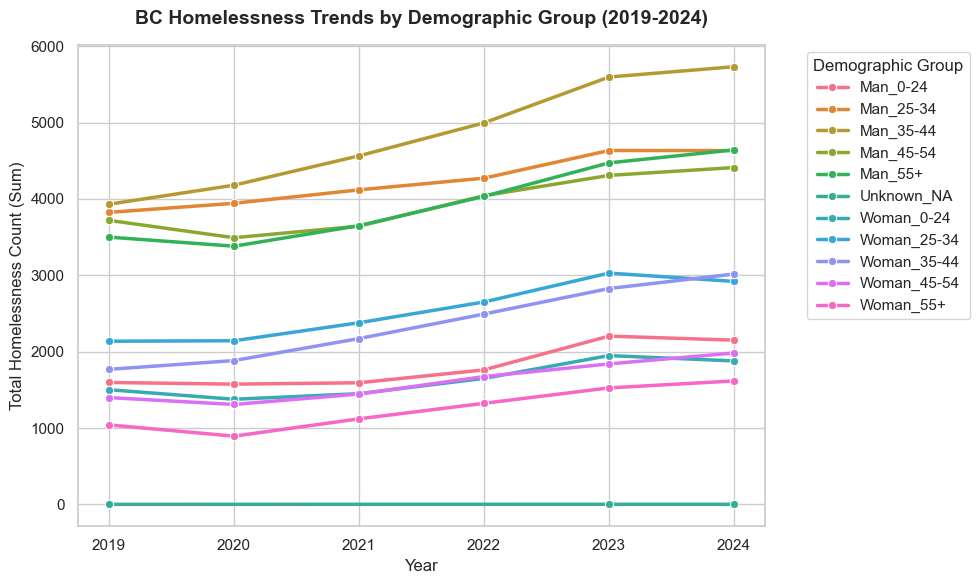

In [20]:
# Apply groupby aggregation or implement one of the backup grouping strategies
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Group the primary data to get the total homelessness count (n) per year and demographic
df_primary_grouped = (
    df_clean.groupby(['year', 'gender_age'])['n']
    .sum()
    .reset_index()
)

# 2. Plot the clean, aggregated trends
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df_primary_grouped, 
    x='year', 
    y='n', 
    hue='gender_age', 
    marker='o', 
    linewidth=2.5
)

# Customize title and labels
plt.title("BC Homelessness Trends by Demographic Group (2019-2024)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Homelessness Count (Sum)", fontsize=12)
plt.xticks(df_primary_grouped['year'].unique())  # Force clean integer year labels

# Place legend nicely on the side
plt.legend(title="Demographic Group", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

- *Extra Credit: Write your economic or policy related interpretation here*

Homelessness increased across demographics in BC from 2019 to 2024, with acceleration (as indicated by the steeper slopes) around 2020 likely explained by the pandemic and its impacts on economic security. However, the fact that homelessness rates have continued to increase since the pandemic and well into the recovery period bears concerning implications for policymakers. The roots of that persistent increase must be identified, hence the deep dive into the correlation (or lack thereof) with unemployment rates in the next section.

### **Part 5: Visualization & Regression Modeling**

- **Visualization Requirements**
  - Generate at least two fully customized, beautiful Matplotlib plots.
  - **Plot 1**: A bar chart or line chart showing aggregated subgroups from Part 4.
  - **Plot 2**: A scatter plot representing the relationship between two primary indicators.
  - **Customizations**: Make sure to customize titles, axis labels, gridlines, colors, and markers for a clean and readable style.
- **Exploratory Modeling**
  - Fit a simple linear regression using `statsmodels` (Level-Level, Log-Level, or Log-Log as discussed in Week 6) to model the policy relationship.
  - Plot the line of best fit directly over your scatter plot.
  - Print the summary table and interpret the slope coefficient.

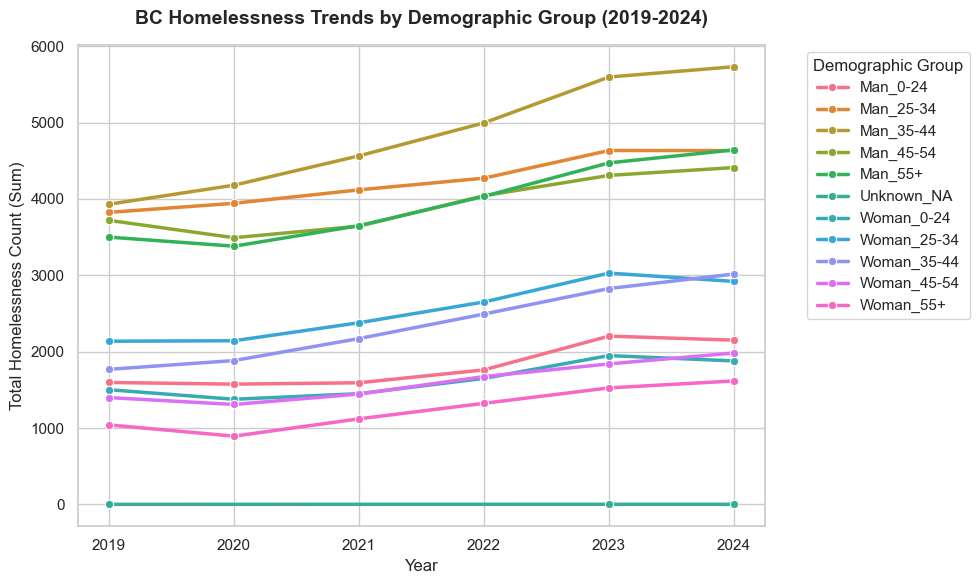

In [21]:
# Plot 1: Customized bar chart or line chart of aggregated subgroups
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aggregate your primary dataset to get clean yearly sums by demographic
df_primary_grouped = (
    df_clean.groupby(['year', 'gender_age'])['n']
    .sum()
    .reset_index()
)

# 2. Set up the plotting theme
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 3. Create the line plot
sns.lineplot(
    data=df_primary_grouped, 
    x='year', 
    y='n', 
    hue='gender_age', 
    marker='o', 
    linewidth=2.5
)

# Customize title and labels
plt.title("BC Homelessness Trends by Demographic Group (2019-2024)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Homelessness Count (Sum)", fontsize=12)
plt.xticks(df_primary_grouped['year'].unique())  # Standardize x-axis markings to actual years

# Place legend on the side so it doesn't overlap lines
plt.legend(title="Demographic Group", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

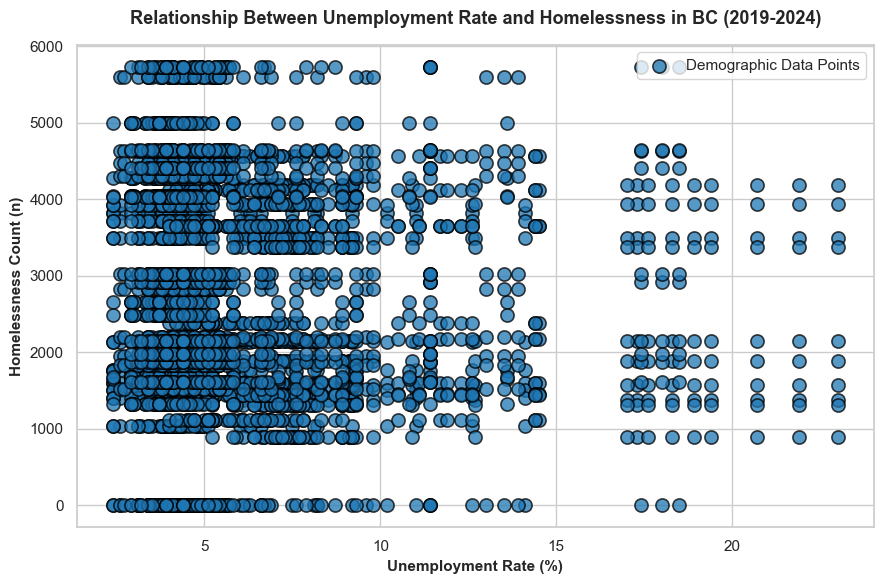

In [26]:
# Plot 2: Customized scatter plot of primary policy variables
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set a clean, professional aesthetic
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

# 2. Plot the customized scatter plot
plt.scatter(
    df_merged['unemployment_rate'], 
    df_merged['n'], 
    color='#1f77b4',          # A nice, solid academic blue
    s=90,                     # Slightly larger markers for readability
    alpha=0.75,                # Subtle transparency to see overlapping points
    edgecolors='black',        # Sharp borders on each point
    linewidths=1.2,
    label='Demographic Data Points'
)

# 3. Add clean labels, styling, and a title
plt.title("Relationship Between Unemployment Rate and Homelessness in BC (2019-2024)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Unemployment Rate (%)", fontsize=11, fontweight='bold')
plt.ylabel("Homelessness Count (n)", fontsize=11, fontweight='bold')

# 4. Optional: Add a subtle legend and optimize the fit
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()

# Display the clean plot
plt.show()

--- Linear Regression Calculations ---
Slope (m): -14.8099
y-intercept (b): 2774.8705
R-squared (R²): 0.0012
P-value: 0.0271
Line Equation: y = -14.81x + 2774.87
--------------------------------------


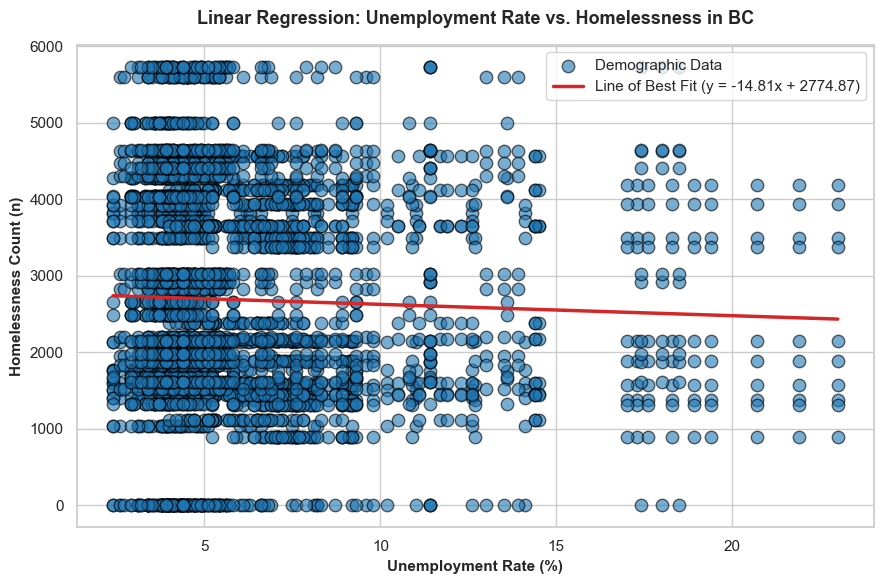

In [27]:
# Fit a simple linear regression and overlay the line of best fit
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import linregress

# 1. Mathematically calculate the linear regression line
# This extracts the slope (m), y-intercept (b), r-value, and other regression stats
slope, intercept, r_value, p_value, std_err = linregress(
    df_merged['unemployment_rate'], 
    df_merged['n']
)

# Print the mathematical results so you can reference them in your write-up
print("--- Linear Regression Calculations ---")
print(f"Slope (m): {slope:.4f}")
print(f"y-intercept (b): {intercept:.4f}")
print(f"R-squared (R²): {r_value**2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Line Equation: y = {slope:.2f}x + {intercept:.2f}")
print("-" * 38)

# 2. Set up the plotting environment
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

# Plot the underlying data points as a reference scatter
plt.scatter(
    df_merged['unemployment_rate'], 
    df_merged['n'], 
    color='#1f77b4', 
    s=80, 
    alpha=0.6, 
    edgecolors='black', 
    label='Demographic Data'
)

# Generate points along our X-axis to draw the mathematically fitted line
x_range = np.linspace(df_merged['unemployment_rate'].min(), df_merged['unemployment_rate'].max(), 100)
# Equation: y = mx + b
y_fit = slope * x_range + intercept

# Plot the calculated Line of Best Fit
plt.plot(
    x_range, 
    y_fit, 
    color='#d62728',          # Vibrant red line
    linewidth=2.5, 
    linestyle='-', 
    label=f'Line of Best Fit (y = {slope:.2f}x + {intercept:.2f})'
)

# Format the plot elements
plt.title("Linear Regression: Unemployment Rate vs. Homelessness in BC", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Unemployment Rate (%)", fontsize=11, fontweight='bold')
plt.ylabel("Homelessness Count (n)", fontsize=11, fontweight='bold')
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()

# Display the final line-of-best-fit visualization
plt.show()

- *Extra Credit: Write your visualization and regression interpretations here*

Line plot: observing homelessness trends over time, there is a clear and persistent upward trend in homelessness over the course of the pandemic and recovery years. While not capturing what the specific drivers of homelessness are, those systemic factors have evidently consistently worsened over the 6-year span. Also, note the clear acceleration around 2020-21, which aligns with the onset of the pandemic. Considering the multidimensional impact of the pandemic on economic security, housing stability, support networks, employment, mental health, this is hardly surprising.

Linear regression: For every 1% increase in the BC unemployment rate, the model predicts that the homelessness count for a given demographic decreases by around 15 people (14.81). This is a counterintuitive result, suggesting that as unemployment rates fell, homelessness counts continued to climb, rather than moving in tandem with the former metric. The R2 value of 0.0012 suggests that unemployment rate has limited predictive power over homelessness rate on its own i.e. only about 0.12% of the variation in homelessness can be accounted for by homelessness, suggesting that other external factors are greater predictors. At the same time, the P-value of 0.0271 is lower than 0.05, suggesting that the negative trend observed is more than just noise. 

The policy implication here may be that policy initiatives focused on job creation will not solve homelessness alone. 

### **Submission Checklist**

- **Out-of-the-Box Execution**
  - Select `Kernel -> Restart & Run All` to verify all cells run without error.
- **Reproducibility & Paths**
  - Verify that both the notebook and the dataset are saved and committed in Git.
  - Ensure all files are loaded using relative paths.
- **Visual Elements & Design**
  - Ensure all plots are fully customized, clearly labeled, and have titles.